# Slide 1 - From Raw Echo Frame to Structured Measurements

## Big Idea
This demo shows the full OCR journey in one clinical echo frame:
1. Load DICOM frame
2. Find measurement panel (ROI)
3. Segment panel into text lines
4. Preprocess each line for OCR
5. Extract text and convert to measurements

## Layout (for presenting)
- Keep this notebook in presentation mode with code hidden when possible.
- For each slide: show markdown first, then run the code cell under it to reveal the image(s).

## Storyline You Can Say
"Everything starts as noisy pixels. The pipeline progressively isolates the signal until OCR becomes reliable enough for structured extraction."

## Demo Setup
- Run all cells top-to-bottom once before presenting.
- Sample DICOM auto-resolves from repo root.
- The figures generated in each section are the images for your slides.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "app" / "pipeline" / "echo_ocr_pipeline.py").is_file():
            return p
    raise RuntimeError("Open this notebook from the Master repo (or a parent path that contains app/pipeline).")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

DICOM_CANDIDATES = [
    REPO / "91243943_0007.dcm",
    REPO / "91243943_00007.dcm",
    REPO / "notebooks" / "91243943_0007.dcm",
]
DICOM_PATH = next((p for p in DICOM_CANDIDATES if p.is_file()), None)
if DICOM_PATH is None:
    raise FileNotFoundError(f"No sample DICOM found. Tried: {DICOM_CANDIDATES}")

print("REPO:", REPO)
print("DICOM:", DICOM_PATH)

REPO: /home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/Master
DICOM: /home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/Master/91243943_0007.dcm


## Slide 2 - Raw Input Frame

## What appears on screen
- One full RGB echocardiography frame.
- This is the exact starting point used by the app pipeline.

## Layout suggestion
- Full-width image.
- Bottom caption: "Unstructured, high-noise clinical image".

## Key message
Before OCR, there is no concept of rows, labels, or values, only pixels.

## Talk track
"At this stage the pipeline knows nothing about where measurements are. It only has a normalized frame loaded from DICOM."

frame shape: (708, 1016, 3) dtype: uint8


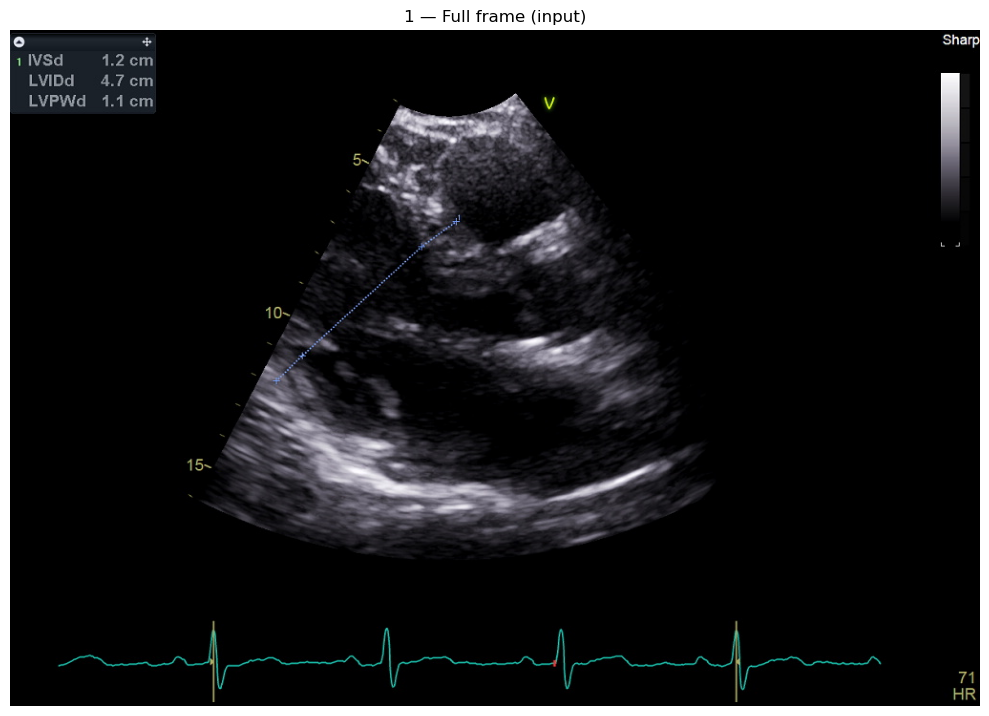

In [2]:
from app.io.dicom_loader import load_dicom_series

series = load_dicom_series(DICOM_PATH, load_pixels=True)
frame = series.raw_frames[0]
print("frame shape:", frame.shape, "dtype:", frame.dtype)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(frame)
ax.set_title("1 — Full frame (input)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Slide 3 - Detect Measurement Panel (ROI Localization)

## What appears on screen
Three panels:
1. Original frame
2. Color-distance debug mask
3. Final bounding box overlay

## Layout suggestion
- Use a 3-column row.
- Emphasize panel 3 with a verbal callout: "this green box is where OCR will happen".

## Key message
We reduce search space early by detecting the vendor-specific blue-gray measurement box in the top-left region.

## Talk track
"Instead of OCR on the entire ultrasound frame, we first isolate the panel. This improves speed and accuracy because downstream steps only process relevant pixels."

RoiDetection(present=True, bbox=(0, 3, 153, 85), confidence=0.9495578623606306)


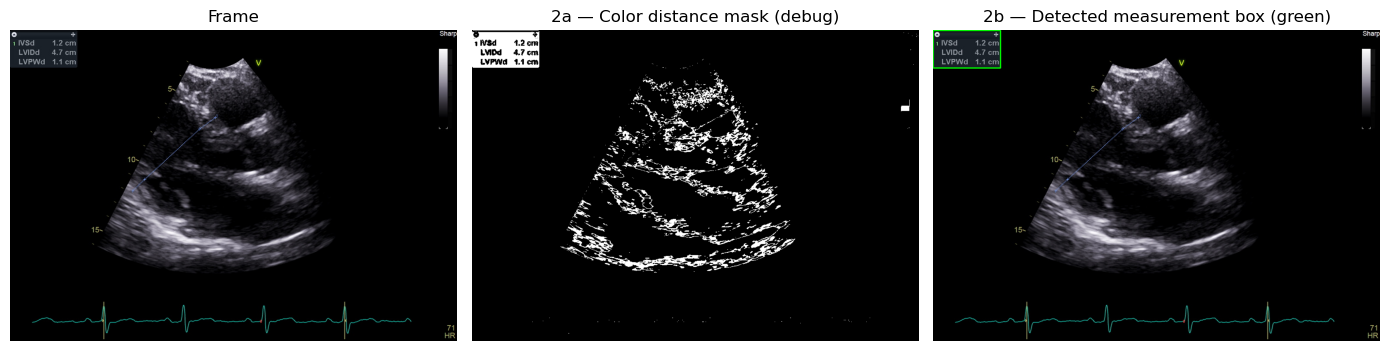

In [3]:
import cv2

from app.pipeline.echo_ocr_box_detector import TopLeftBlueGrayBoxDetector, _color_distance

detector = TopLeftBlueGrayBoxDetector()
detection = detector.detect(frame)
print(detection)

if not detection.present or detection.bbox is None:
    raise RuntimeError("ROI not found — check frame / detector parameters.")

rgb = frame[..., :3].astype(np.int16)
dist = _color_distance(rgb, detector.box_color)
mask = (dist <= detector.color_tolerance).astype(np.uint8) * 255

x, y, bw, bh = detection.bbox
overlay = frame.copy()
cv2.rectangle(overlay, (x, y), (x + bw, y + bh), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(frame)
axes[0].set_title("Frame")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("2a — Color distance mask (debug)")
axes[2].imshow(overlay)
axes[2].set_title("2b — Detected measurement box (green)")
for a in axes:
    a.axis("off")
plt.tight_layout()
plt.show()

## Slide 4 - Crop the ROI

## What appears on screen
- A tall cropped measurement panel.
- This array is passed to segmentation and OCR logic.

## Layout suggestion
- Single centered image.
- Add one short annotation: "All downstream logic now runs inside this crop".

## Key message
Cropping removes irrelevant anatomy and machine overlays, letting subsequent models focus on dense text zones.

## Talk track
"This is the first major simplification: full frame to focused panel. Every later operation uses coordinates relative to this ROI."

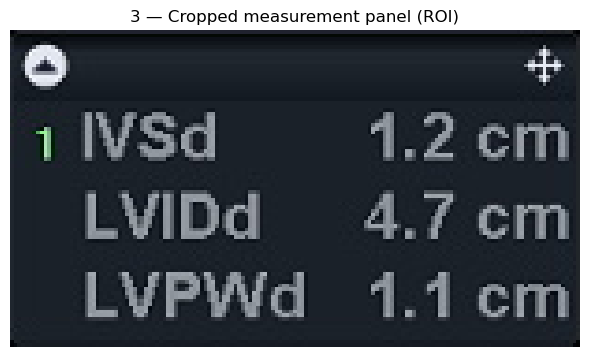

In [4]:
roi = frame[y : y + bh, x : x + bw].copy()
fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(roi)
ax.set_title("3 — Cropped measurement panel (ROI)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Slide 5 - Scout OCR Pass on Whole ROI

## What appears on screen
- Left: raw ROI fed into scout OCR.
- Right: optional demo overlay of word boxes (Tesseract visualization).

## Layout suggestion
- 2-column comparison.
- Left column title: "Input to scout pass".
- Right column title: "Token geometry preview".

## Key message
A fast whole-panel OCR pass gives rough textual/positional cues before fine-grained per-line transcription.

## Talk track
"Think of this as reconnaissance. We get an early estimate of where text lives and what it might contain before detailed line-level extraction."

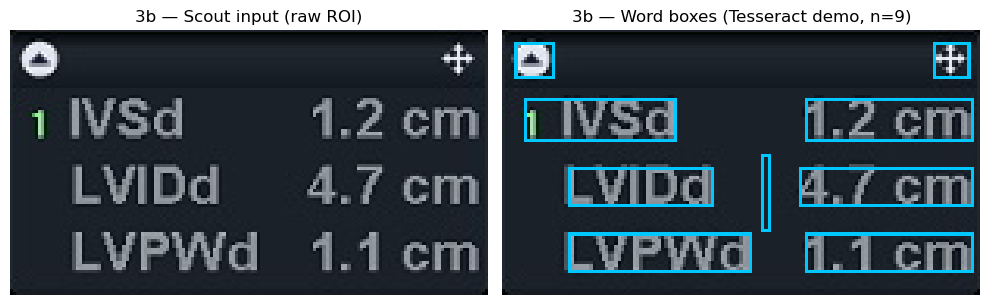

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].imshow(roi)
axes[0].set_title("3b — Scout input (raw ROI)")
axes[0].axis("off")

scout_vis = roi.copy()
n_boxes = 0
try:
    import pytesseract
    from pytesseract import Output

    gray_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY) if roi.ndim == 3 else roi
    data = pytesseract.image_to_data(gray_roi, output_type=Output.DICT, config="--oem 3 --psm 6")
    for i, txt in enumerate(data.get("text", [])):
        if not str(txt).strip():
            continue
        try:
            conf = int(data["conf"][i])
        except (TypeError, ValueError):
            conf = -1
        if conf < 0:
            continue
        xa, ya, wa, ha = data["left"][i], data["top"][i], data["width"][i], data["height"][i]
        cv2.rectangle(scout_vis, (xa, ya), (xa + wa, ya + ha), (0, 200, 255), 1)
        n_boxes += 1
    axes[1].imshow(scout_vis)
    axes[1].set_title(f"3b — Word boxes (Tesseract demo, n={n_boxes})")
except Exception as exc:
    axes[1].text(
        0.5,
        0.5,
        "Install `tesseract` + `pytesseract` for word boxes,\nor run GLM/Surya scout in the app.\n\n"
        + str(exc),
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        fontsize=9,
    )
    axes[1].set_title("3b — No Tesseract word overlay")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Slide 6 - Segment ROI into Ordered Text Lines

## What appears on screen
- ROI with blue line boxes and order numbers.
- Printed debug info (line count, trim, segmentation metadata).

## Layout suggestion
- Main visual large.
- Keep debug text visible under figure as "technical proof".

## Key message
The pipeline converts one dense text panel into ordered, line-level reading units.

## Talk track
"Segmentation creates deterministic reading order, which is critical for mapping OCR text back to expected measurement patterns."

header_trim_px: 18
lines: 3
debug: {'line_count': 3, 'header_trim_px': 18, 'refined_line_splits': 0, 'segmentation_mode': 'fixed_pitch', 'target_line_height_px': 20.0, 'estimated_line_count': 3}


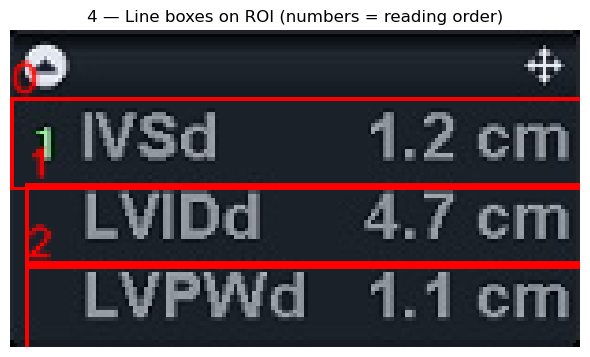

In [6]:
from app.pipeline.echo_ocr_pipeline import (
    DEFAULT_HEADER_TRIM_PX,
    DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
    DEFAULT_SEGMENTATION_MODE,
    DEFAULT_TARGET_LINE_HEIGHT_PX,
)
from app.pipeline.line_segmenter import LineSegmenter

segmenter = LineSegmenter(
    segmentation_mode=DEFAULT_SEGMENTATION_MODE,
    target_line_height_px=DEFAULT_TARGET_LINE_HEIGHT_PX,
    default_header_trim_px=DEFAULT_HEADER_TRIM_PX,
    extra_left_pad_px=DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
)
segmentation = segmenter.segment(roi, tokens=None)
print("header_trim_px:", segmentation.header_trim_px)
print("lines:", len(segmentation.lines))
print("debug:", segmentation.debug)

vis = roi.copy()
for line in segmentation.lines:
    lx, ly, lw, lh = line.bbox
    cv2.rectangle(vis, (lx, ly), (lx + lw, ly + lh), (255, 0, 0), 1)
    cv2.putText(
        vis,
        str(line.order),
        (lx, max(0, ly - 2)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.35,
        (255, 0, 0),
        1,
        cv2.LINE_AA,
    )

fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(vis)
ax.set_title("4 — Line boxes on ROI (numbers = reading order)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Slide 7 - Raw Line Crops

## What appears on screen
- Grid of per-line RGB crops.
- Each tile is one OCR unit consumed by the line transcriber.

## Layout suggestion
- Show as gallery/grid.
- Mention that line order in the grid follows segmentation order.

## Key message
This is where the task changes from document detection to focused micro-OCR on small text strips.

## Talk track
"Each crop is tiny but information-dense. At this scale, preprocessing choices have a big impact on recognition quality."

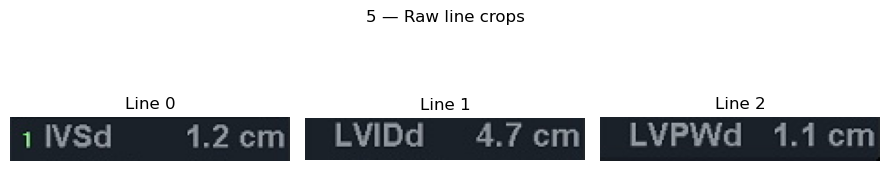

In [7]:
from app.pipeline.line_transcriber import crop_segment

line_crops = [crop_segment(roi, seg) for seg in segmentation.lines]
n = len(line_crops)
cols = min(4, max(1, n))
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.2 * rows))
axes = np.atleast_1d(axes).ravel()
for i, crop in enumerate(line_crops):
    axes[i].imshow(crop)
    axes[i].set_title(f"Line {i}")
    axes[i].axis("off")
for j in range(len(line_crops), len(axes)):
    axes[j].axis("off")
plt.suptitle("5 — Raw line crops", y=1.02)
plt.tight_layout()
plt.show()

## Slide 8 - Preprocessing Pipeline (One Line, Step by Step)

## What appears on screen
Three-panel comparison for one line:
1. Raw grayscale (same resolution as the line crop)
2. **×3 Lanczos grayscale only** — input style that scored best for **GLM-OCR** in the broad preprocessing sweep (no unsharp, no Otsu, no morph)
3. **Default binarized pipeline** — unsharp → ×3 Lanczos → Otsu → morph close (still useful for Tesseract-style engines)

## Preprocessing experiments (GLM-OCR, labeled validation)
We ran a headless sweep over 15 line-preprocessing configs (`app/tools/sweep_preprocessing_headless.py`, results under `artifacts/ocr_redesign/preprocess_sweep_glm_broad/`). On the p10 validation slice (490 labeled lines), **top exact match (~95.5%)** tied **gray_x3_lanczos**, **no_preprocess_gray** (1× gray), and **unsharp_x3_lanczos**; among those, **gray_x3_lanczos** is the practical pick (upscale for small crops, fewer moving parts than the full panel default). **Adaptive-threshold** variants scored much lower (~39% exact). The default Otsu+morph stack sat around **~94.5%** exact with occasional file-level OCR errors.

## Layout suggestion
- One row, three equal columns: gray → GLM-optimal upscale → binarized default.
- Optional verbal contrast: “vision model vs. classical OCR want different pixels.”

## Key message
Preprocessing is not one recipe for every engine: GLM-OCR did best on **continuous-tone upscaled gray**; the binarized pipeline remains the classic choice for legacy OCR.

## Talk track
"We benchmarked many recipes. For GLM, simple grayscale plus a strong upscale beat our heavy binarization path on labeled validation—so the notebook and demos use that for the neural transcriber while we keep the binarized path for comparison and for Tesseract-style stacks."

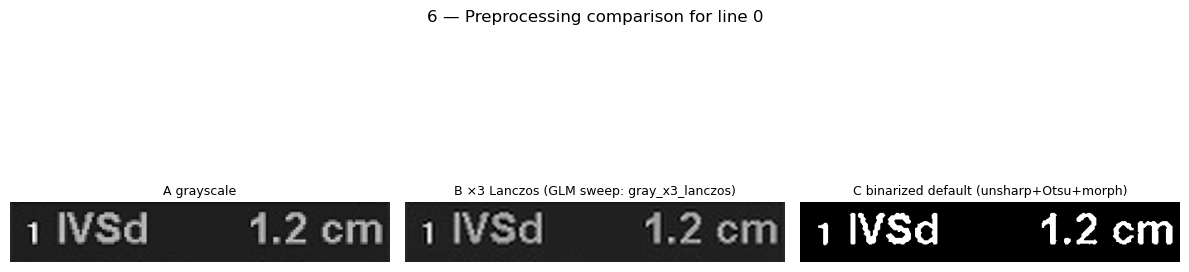

In [8]:
LINE_IX = 0

from app.ocr.preprocessing import (
    DEFAULT_CONTRAST_MODE,
    DEFAULT_SCALE_ALGO,
    DEFAULT_SCALE_FACTOR,
    _to_gray,
    preprocess_gray_x3_lanczos,
    preprocess_roi,
)

if LINE_IX >= len(line_crops):
    raise IndexError("LINE_ix out of range — no line crops.")

crop = line_crops[LINE_IX]
stages = {
    "A grayscale": _to_gray(crop),
    "B ×3 Lanczos (GLM sweep: gray_x3_lanczos)": preprocess_gray_x3_lanczos(crop),
    "C binarized default (unsharp+Otsu+morph)": preprocess_roi(
        crop,
        scale_factor=DEFAULT_SCALE_FACTOR,
        scale_algo=DEFAULT_SCALE_ALGO,
        contrast_mode=DEFAULT_CONTRAST_MODE,
    ),
}
keys = list(stages.keys())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, keys):
    im = stages[k]
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(k, fontsize=9)
    ax.axis("off")
plt.suptitle(f"6 — Preprocessing comparison for line {LINE_IX}", y=1.02)
plt.tight_layout()
plt.show()

## Slide 9 - Multi-View Strategy for Hard Lines

## What appears on screen
- Three OCR-ready views of the same line:
  - **gray_x3_lanczos** (GLM-optimized from the sweep — primary view in this notebook)
  - **default** binarized pipeline (unsharp + Otsu + morph)
  - **clahe** variant (CLAHE + same binarization stack as `preprocess_roi`)

## Layout suggestion
- 3 equal columns.
- Optional prompt: “Neural OCR vs. binarized classical input — which preserves the numbers you care about?”

## Key message
The production app can still try alternates for hard lines; labeled benchmarking showed **continuous upscaled gray** ahead for GLM on this dataset, with **adaptive-threshold** views much weaker in the sweep.

## Talk track
"We keep multiple renderings for robustness, but we anchor the story on what actually won on validation: upscale grayscale for GLM, with the old binarized recipe alongside for comparison and for Tesseract-class engines."

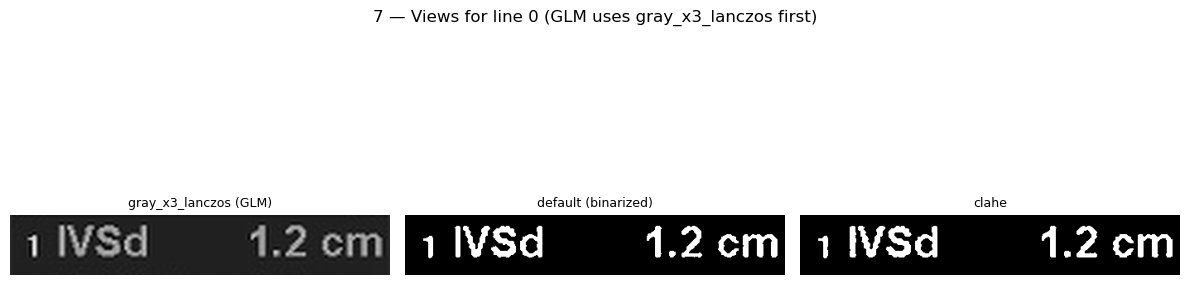

In [9]:
from app.ocr.preprocessing import preprocess_gray_x3_lanczos, preprocess_roi

views = {
    "gray_x3_lanczos (GLM)": preprocess_gray_x3_lanczos(line_crops[LINE_IX]),
    "default (binarized)": preprocess_roi(
        line_crops[LINE_IX],
        scale_factor=DEFAULT_SCALE_FACTOR,
        scale_algo=DEFAULT_SCALE_ALGO,
        contrast_mode=DEFAULT_CONTRAST_MODE,
    ),
    "clahe": preprocess_roi(
        line_crops[LINE_IX],
        scale_factor=DEFAULT_SCALE_FACTOR,
        scale_algo=DEFAULT_SCALE_ALGO,
        contrast_mode="clahe",
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, img) in zip(axes, views.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.suptitle(f"7 — Views for line {LINE_IX} (GLM uses gray_x3_lanczos first)", y=1.05)
plt.tight_layout()
plt.show()

## Slide 10 - OCR Extraction and Structured Output

## What appears on screen
- Optional GLM-OCR run on each line with **`preprocess_gray_x3_lanczos`** (same as broad sweep winner `gray_x3_lanczos`).
- Console output with extracted text, confidence, and token counts.
- Optional full pipeline run that emits parsed measurements (still uses app pipeline defaults, not this notebook-only preprocessor).

## Layout suggestion
- Split attention: left for line image recap, right for textual OCR results.
- End with one sentence on structured fields (name, value, unit).

## Key message
After progressive cleanup and segmentation, OCR outputs become stable enough to transform into clinical measurement records.

## Talk track
"The final value is not only recognized text, but structured measurements that can feed analytics, QA, and reporting workflows."

The image processor of type `Glm46VImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Engine ready: glm-ocr (line crops: preprocess_gray_x3_lanczos)
line 0: '1 IVSd 1.2 cm' (conf=0.990, tokens=1)
line 1: 'LVIDd 4.7cm' (conf=0.990, tokens=1)
line 2: 'LVPWd 1.1cm' (conf=0.990, tokens=1)


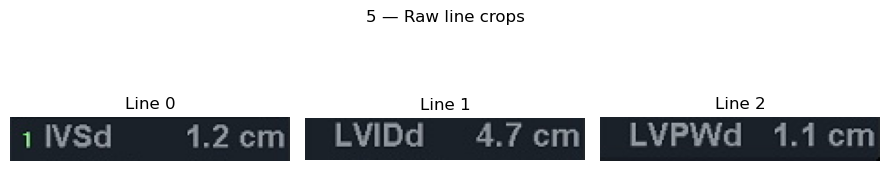

Interrupted system call ; error code 4


In [10]:
# GLM-OCR (optional): worker loads in the `glm_ocr` conda env — startup can take ~minutes the first time.
RUN_GLM_OCR = True
RUN_GLM_FULL_PIPELINE = False

from app.ocr.preprocessing import (
    DEFAULT_CONTRAST_MODE,
    DEFAULT_SCALE_ALGO,
    DEFAULT_SCALE_FACTOR,
    preprocess_gray_x3_lanczos,
    preprocess_roi,
)

if RUN_GLM_OCR:
    from app.pipeline.ocr_engines import UnavailableOcrEngineError, build_engine

    try:
        glm = build_engine("glm-ocr")
    except UnavailableOcrEngineError as exc:
        print("GLM-OCR unavailable:", exc)
        print(
            "Fix:\n"
            "  mamba env update -f envs/glm_ocr.yml --prune\n"
            "The app also probes ~/miniforge3, ~/mambaforge, $CONDA_EXE, etc. if mamba is not on PATH.\n"
            "Or: GLM_OCR_RUNNER=python and pip-install the pip: section of envs/glm_ocr.yml into this kernel."
        )
    except Exception as exc:
        print("GLM-OCR failed to start:", exc)
    else:
        print(f"Engine ready: {glm.name} (line crops: preprocess_gray_x3_lanczos)")
        for i, crop in enumerate(line_crops):
            proc = preprocess_gray_x3_lanczos(crop)
            result = glm.extract(proc)
            print(
                f"line {i}: {result.text!r} "
                f"(conf={result.confidence:.3f}, tokens={len(result.tokens)})"
            )

if RUN_GLM_FULL_PIPELINE:
    from app.models.types import PipelineRequest
    from app.pipeline.ai_pipeline import PipelineConfig
    from app.pipeline.echo_ocr_pipeline import EchoOcrPipeline

    dicom_path = DICOM_PATH
    if dicom_path is None:
        raise RuntimeError("Run the setup cell first — no sample DICOM (DICOM_PATH is unset).")

    pipe = EchoOcrPipeline(
        config=PipelineConfig(
            parameters={
                "max_frames": 1,
                "ocr_engine": "glm-ocr",
            }
        )
    )
    pipe.ensure_components()
    res = pipe.run(PipelineRequest(dicom_path=dicom_path, parameters={"max_frames": 1}))
    print("Full pipeline:", res.status, res.error)
    if res.ai_result:
        for m in res.ai_result.measurements:
            print(m.name, m.value, m.unit)

if not RUN_GLM_OCR and not RUN_GLM_FULL_PIPELINE:
    print("Set RUN_GLM_OCR or RUN_GLM_FULL_PIPELINE to True to run GLM-OCR.")

#show the line crops
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.2 * rows))
axes = np.atleast_1d(axes).ravel()
for i, crop in enumerate(line_crops):
    axes[i].imshow(crop)
    axes[i].set_title(f"Line {i}")
    axes[i].axis("off")
plt.suptitle("5 — Raw line crops", y=1.02)
plt.tight_layout()
plt.show()

# Tesseract on lines (no GLM env): swap engine
# engine = build_engine("tesseract")
# for i, crop in enumerate(line_crops):
#     proc = preprocess_roi(crop, scale_factor=DEFAULT_SCALE_FACTOR, scale_algo=DEFAULT_SCALE_ALGO, contrast_mode=DEFAULT_CONTRAST_MODE)
#     print(i, repr(engine.extract(proc).text))

## Slide 11 - End-to-End Recap and Q&A

## Pipeline Summary
Raw DICOM frame -> ROI detection -> line segmentation -> per-line preprocessing -> OCR -> parsed measurements

## Suggested final layout
- Left: Keep one representative figure visible (ROI with line boxes or preprocessing gallery).
- Right: Show 3 impact bullets:
  1. Faster OCR by reducing search area
  2. Better accuracy through targeted preprocessing
  3. Structured extraction ready for downstream validation

## 30-second close
"This pipeline turns a noisy clinical frame into machine-usable measurement data through staged visual narrowing. Each stage is inspectable, debuggable, and measurable, which makes it practical for both research and production QA."

## Optional backup slides (if asked)
- Compare OCR outputs between default/high_contrast/clahe for a difficult line.
- Run full pipeline with GLM and show parsed measurement tuples.